================================================================================

TCC: SEGURANÇA NA INDÚSTRIA 4.0

ARQUITETURA HÍBRIDA SEQUENCIAL EM CASCATA: K-MEANS -> DBSCAN

Dataset: RAW_DATA (Sudyana, Didik)


===============================================================================

ETAPA 1 - IMPORTAÇÕES

In [48]:
# =============================================================================
# ETAPA 1 - IMPORTAÇÕES
# =============================================================================
import os
import glob
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from scipy.stats import mode
from scipy.stats import ttest_rel

ETAPA 2 - MONTAGEM E CAMINHO BASE - DRIVE

In [49]:
# =============================================================================
# ETAPA 2 - DOWNLOAD/CARREGAMENTO DO DATASET (ZENODO)
# =============================================================================
DATA_PATH = "data"
ZIP_FILE = os.path.join(DATA_PATH, "raw_data.zip")
PATH_BASE = os.path.join(DATA_PATH, "raw_data")

ZENODO_URL = "https://zenodo.org/records/17165850/files/raw_data.zip"

os.makedirs(DATA_PATH, exist_ok=True)

if not os.path.exists(PATH_BASE):
    if not os.path.exists(ZIP_FILE):
        print("Baixando dataset do Zenodo...")
        !wget -O "{ZIP_FILE}" "{ZENODO_URL}"

    print("Extraindo dataset...")
    with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
        zip_ref.extractall(DATA_PATH)

print(f"Dataset carregado em: {PATH_BASE}")

Dataset carregado em: data/raw_data


ETAPA 3 - CONFIGURAÇÕES DO EXPERIMENTO

In [50]:
# =============================================================================
# ETAPA 3 - CONFIGURAÇÕES DO EXPERIMENTO
# =============================================================================
USE_PCA = True
PCA_VAR = 0.95
SEED_BASE = 42
TEST_SIZE = 0.30

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

AMOSTRA_TUNING = 15000
AMOSTRA_TESTE_DBSCAN = 20000
AMOSTRA_HIBRIDO = 20000

USE_P85 = False
P85 = 85

GRID_PGATE = [70, 75, 80, 85, 88, 90, 92, 95]
FPR_ALVO = 0.05

N_TESTE_CENARIO_A = 20000
PERCENTIL_KMEANS = 99
RODAR_HIBRIDO_V1 = True
RODAR_HIBRIDO_V2 = True

ETAPA 4 - CARREGAMENTO DO DATASET (RAW_DATA)

In [51]:
# =============================================================================
# ETAPA 4 - CARREGAMENTO DO DATASET (RAW_DATA)
# =============================================================================
lista_csv = glob.glob(os.path.join(PATH_BASE, "**/*.csv"), recursive=True)
dfs = []

for arquivo in lista_csv:
    try:
        if "zone.identifier" in arquivo.lower():
            continue

        df_temp = pd.read_csv(arquivo)
        if df_temp.empty:
            continue

        caminho = arquivo.lower()
        if "/attack/" in caminho or "\\attack\\" in caminho:
            df_temp["Label"] = 1
        elif "/normal/" in caminho or "\\normal\\" in caminho:
            df_temp["Label"] = 0
        elif "/fault/" in caminho or "\\fault\\" in caminho:
            df_temp["Label"] = 1
        else:
            continue

        dfs.append(df_temp)

    except Exception as e:
        print(f"Erro ao ler {arquivo}: {e}")

if not dfs:
    raise ValueError(
        "Nenhum CSV válido foi encontrado no dataset. "
        "Verifique a estrutura da pasta raw_data."
    )

df = pd.concat(dfs, ignore_index=True)
print("Shape original:", df.shape)
print("Distribuição das classes:\n", df["Label"].value_counts())

Shape original: (535112, 31)
Distribuição das classes:
 Label
0    497476
1     37636
Name: count, dtype: int64


ETAPA 5 - LIMPEZA E PREPARAÇÃO

In [52]:

# =============================================================================
# ETAPA 5 - LIMPEZA E PREPARAÇÃO
# =============================================================================
df = df.select_dtypes(exclude=["object"])

y = df["Label"].copy()
X = df.drop(columns=["Label"]).copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("NaN:", np.isnan(X).sum().sum(), "| Inf:", np.isinf(X).sum().sum())

NaN: 0 | Inf: 0


ETAPA 6 - BALANCEAMENTO (UNDERSAMPLING)

In [53]:
# =============================================================================
# ETAPA 6 - BALANCEAMENTO (UNDERSAMPLING)
# =============================================================================
df_tmp = X.copy()
df_tmp["Label"] = y

df_0 = df_tmp[df_tmp["Label"] == 0]
df_1 = df_tmp[df_tmp["Label"] == 1]

n = min(len(df_0), len(df_1))

df_balanceado = pd.concat([
    df_0.sample(n, random_state=SEED_BASE),
    df_1.sample(n, random_state=SEED_BASE)
]).sample(frac=1, random_state=SEED_BASE)

y = df_balanceado["Label"]
X = df_balanceado.drop(columns=["Label"])

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Distribuição após balanceamento:\n", y.value_counts())

Distribuição após balanceamento:
 Label
1    37636
0    37636
Name: count, dtype: int64


FUNÇÕES AUXILIARES (MÉTRICAS + AMOSTRAGEM)

In [54]:
# =============================================================================
# ETAPA 7 - FUNÇÕES AUXILIARES
# =============================================================================
def calcular_metricas(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return acc, prec, rec, f1, fpr, (tn, fp, fn, tp)


def amostrar_indices(n_total, n_amostra, seed=42):
    if n_total <= n_amostra:
        return np.arange(n_total)
    rng = np.random.default_rng(seed)
    return rng.choice(np.arange(n_total), size=n_amostra, replace=False)


def preprocessar_seed(X_raw, y_raw, seed, use_pca=False, pca_var=0.95):
    X_train_raw, X_test_raw, y_train_s, y_test_s = train_test_split(
        X_raw, y_raw, test_size=TEST_SIZE, random_state=seed, stratify=y_raw
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_raw)
    X_test_s = scaler.transform(X_test_raw)

    if use_pca:
        pca = PCA(n_components=pca_var, random_state=seed)
        X_train_s = pca.fit_transform(X_train_s)
        X_test_s = pca.transform(X_test_s)

    return X_train_s, X_test_s, np.array(y_train_s), np.array(y_test_s)


def kmeans_ids_percentil(X_train_arr, X_test_arr, percentil=99, seed=42):
    km = KMeans(n_clusters=2, random_state=seed, n_init=10)
    km.fit(X_train_arr)
    labels = km.predict(X_test_arr)
    centroids = km.cluster_centers_
    dist = np.linalg.norm(X_test_arr - centroids[labels], axis=1)
    thr = np.percentile(dist, percentil)
    y_pred = (dist > thr).astype(int)
    return y_pred, thr


def avaliar_dbscan_ids(X_arr, y_arr, eps, min_samples):
    db = DBSCAN(eps=eps, min_samples=min_samples, algorithm="ball_tree", n_jobs=-1)
    labels = db.fit_predict(X_arr)
    y_pred = (labels == -1).astype(int)
    return f1_score(y_arr, y_pred, zero_division=0)


def hibrido_v1_pred(X_train_arr, X_test_arr, seed, eps, ms, use_p85=False, p85=85, amostra=20000):
    km = KMeans(n_clusters=2, random_state=seed, n_init=10)
    km.fit(X_train_arr)

    labels_test = km.predict(X_test_arr)
    counts = np.bincount(labels_test)
    cluster_suspeito = int(np.argmin(counts))

    idx_cluster = np.where(labels_test == cluster_suspeito)[0]
    X_cluster = X_test_arr[idx_cluster]

    if use_p85 and len(X_cluster) > 0:
        centroid = km.cluster_centers_[cluster_suspeito]
        dist = np.linalg.norm(X_cluster - centroid, axis=1)
        thr = np.percentile(dist, p85)
        idx_ref = idx_cluster[dist >= thr]
    else:
        idx_ref = idx_cluster

    y_pred = np.zeros(len(X_test_arr), dtype=int)
    if len(idx_ref) == 0:
        return y_pred

    sample_size = len(idx_ref) if amostra is None else min(amostra, len(idx_ref))
    idx_sel = idx_ref[amostrar_indices(len(idx_ref), sample_size, seed=seed)]
    X_ref = X_test_arr[idx_sel]

    db = DBSCAN(eps=eps, min_samples=ms, algorithm="ball_tree", n_jobs=-1)
    labels = db.fit_predict(X_ref)
    y_pred[idx_sel] = (labels == -1).astype(int)
    return y_pred


def hibrido_v2_pred(X_train_arr, X_test_arr, seed, eps, ms, p_gate=90, amostra=20000):
    km = KMeans(n_clusters=2, random_state=seed, n_init=10)
    km.fit(X_train_arr)

    labels_tr = km.predict(X_train_arr)
    centroids = km.cluster_centers_
    dist_tr = np.linalg.norm(X_train_arr - centroids[labels_tr], axis=1)
    thr = np.percentile(dist_tr, p_gate)

    labels_te = km.predict(X_test_arr)
    dist_te = np.linalg.norm(X_test_arr - centroids[labels_te], axis=1)
    idx_sus = np.where(dist_te >= thr)[0]

    y_pred = np.zeros(len(X_test_arr), dtype=int)
    if len(idx_sus) == 0:
        return y_pred

    sample_size = len(idx_sus) if amostra is None else min(amostra, len(idx_sus))
    idx_sel = idx_sus[amostrar_indices(len(idx_sus), sample_size, seed=seed)]
    X_ref = X_test_arr[idx_sel]

    db = DBSCAN(eps=eps, min_samples=ms, algorithm="ball_tree", n_jobs=-1)
    labels = db.fit_predict(X_ref)
    y_pred[idx_sel] = (labels == -1).astype(int)
    return y_pred


def metricas_f1_fpr(y_true, y_pred):
    _, _, _, f1v, fprv, _ = calcular_metricas(y_true, y_pred)
    return f1v, fprv


def escolher_melhor_pgate(df_mean):
    if FPR_ALVO is None:
        return int(df_mean.sort_values("F1_mean", ascending=False).iloc[0]["p_gate"])

    candidatos = df_mean[df_mean["FPR_mean"] <= FPR_ALVO]
    if len(candidatos) == 0:
        return int(df_mean.sort_values("F1_mean", ascending=False).iloc[0]["p_gate"])

    return int(candidatos.sort_values("F1_mean", ascending=False).iloc[0]["p_gate"])


def subset_suspeito_treino(X_train_arr, seed, p_gate):
    km = KMeans(n_clusters=2, random_state=seed, n_init=10)
    km.fit(X_train_arr)
    labels_tr = km.predict(X_train_arr)
    centroids = km.cluster_centers_
    dist_tr = np.linalg.norm(X_train_arr - centroids[labels_tr], axis=1)
    thr = np.percentile(dist_tr, p_gate)
    idx = np.where(dist_tr >= thr)[0]
    return idx


def media_dp(v):
    return float(np.mean(v)), float(np.std(v))


def avaliar_cenario_A_multi_seed(
    X_raw, y_raw, seeds, use_pca=True, pca_var=0.95,
    n_teste=20000, best_eps=0.05, best_ms=10,
    melhor_pg=85, percentil_kmeans=99
):
    rows = []

    for s in seeds:
        X_train_s, X_test_s, y_train_s, y_test_s = preprocessar_seed(
            X_raw, y_raw, seed=s, use_pca=use_pca, pca_var=pca_var
        )

        idx_test = amostrar_indices(len(X_test_s), min(n_teste, len(X_test_s)), seed=s)
        X_test_A = X_test_s[idx_test]
        y_test_A = np.array(y_test_s)[idx_test]

        y_pred_km, thr_km = kmeans_ids_percentil(
            X_train_s, X_test_A, percentil=percentil_kmeans, seed=s
        )
        acc, prec, rec, f1, fpr, cm = calcular_metricas(y_test_A, y_pred_km)
        rows.append([s, "KMeans_IDS", acc, prec, rec, f1, fpr, thr_km, cm])

        db = DBSCAN(eps=best_eps, min_samples=best_ms, algorithm="ball_tree", n_jobs=-1)
        labels_db = db.fit_predict(X_test_A)
        y_pred_db = (labels_db == -1).astype(int)
        acc, prec, rec, f1, fpr, cm = calcular_metricas(y_test_A, y_pred_db)
        rows.append([s, "DBSCAN_Puro", acc, prec, rec, f1, fpr, None, cm])

        if RODAR_HIBRIDO_V1:
            y_pred_v1 = hibrido_v1_pred(
                X_train_s, X_test_A, seed=s, eps=best_eps, ms=best_ms,
                use_p85=USE_P85, p85=P85, amostra=None
            )
            acc, prec, rec, f1, fpr, cm = calcular_metricas(y_test_A, y_pred_v1)
            rows.append([s, "Hibrido_v1", acc, prec, rec, f1, fpr, None, cm])

        if RODAR_HIBRIDO_V2:
            y_pred_v2 = hibrido_v2_pred(
                X_train_s, X_test_A, seed=s, eps=best_eps_v2, ms=best_ms_v2,
                p_gate=melhor_pg, amostra=None
            )
            acc, prec, rec, f1, fpr, cm = calcular_metricas(y_test_A, y_pred_v2)
            rows.append([s, "Hibrido_v2", acc, prec, rec, f1, fpr, melhor_pg, cm])

    df_por_seed = pd.DataFrame(rows, columns=[
        "Seed", "Modelo", "Acc", "Prec", "Rec", "F1", "FPR", "Param_Extra", "CM(tn,fp,fn,tp)"
    ])

    agg = df_por_seed.groupby("Modelo").agg(
        Acc_mean=("Acc", "mean"), Acc_std=("Acc", "std"),
        Prec_mean=("Prec", "mean"), Prec_std=("Prec", "std"),
        Rec_mean=("Rec", "mean"), Rec_std=("Rec", "std"),
        F1_mean=("F1", "mean"), F1_std=("F1", "std"),
        FPR_mean=("FPR", "mean"), FPR_std=("FPR", "std"),
    ).reset_index()

    return df_por_seed, agg

ETAPA 8 - PIPELINE SEM VAZAMENTO (SEED BASE)

In [55]:
# =============================================================================
# ETAPA 8 - PIPELINE SEM VAZAMENTO (SEED BASE)
# =============================================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED_BASE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

if USE_PCA:
    pca = PCA(n_components=PCA_VAR, random_state=SEED_BASE)
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)
    print(f"PCA ativo: var={PCA_VAR}, componentes={pca.n_components_}")
else:
    print("PCA desativado")


PCA ativo: var=0.95, componentes=9


ETAPA 9 - BASELINE 1: KMEANS IDS POR DISTÂNCIA (P99)

In [56]:
# =============================================================================
# ETAPA 9 - BASELINE 1: KMEANS IDS POR DISTÂNCIA (P99)
# =============================================================================
y_pred_km, thr_km = kmeans_ids_percentil(X_train, X_test, percentil=99, seed=SEED_BASE)
acc_km, prec_km, rec_km, f1_km, fpr_km, (tn_km, fp_km, fn_km, tp_km) = calcular_metricas(
    np.array(y_test), y_pred_km
)

print("\n===== BASELINE KMEANS (P99) =====")
print(f"thr={thr_km:.4f}")
print(f"Accuracy : {acc_km:.4f}")
print(f"Precision: {prec_km:.4f}")
print(f"Recall   : {rec_km:.4f}")
print(f"F1-score : {f1_km:.4f}")
print(f"FPR      : {fpr_km:.4f}")
print(f"CM (TN,FP,FN,TP) = ({tn_km}, {fp_km}, {fn_km}, {tp_km})")


===== BASELINE KMEANS (P99) =====
thr=5.1599
Accuracy : 0.5027
Precision: 0.6327
Recall   : 0.0127
F1-score : 0.0248
FPR      : 0.0074
CM (TN,FP,FN,TP) = (11208, 83, 11148, 143)


ETAPA 10 - BASELINE 2: DBSCAN PURO (TUNING LEVE NO TREINO)

In [57]:
# =============================================================================
# ETAPA 10 - BASELINE 2: DBSCAN PURO (TUNING LEVE NO TREINO)
# =============================================================================
idx_tune = amostrar_indices(len(X_train), min(AMOSTRA_TUNING, len(X_train)), seed=SEED_BASE)
X_tune = X_train[idx_tune]
y_tune = np.array(y_train)[idx_tune]

grid_eps = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
grid_ms = [3, 5, 8, 10]

best_eps, best_ms, best_f1 = None, None, -1

for eps in grid_eps:
    for ms in grid_ms:
        f1v = avaliar_dbscan_ids(X_tune, y_tune, eps, ms)
        if f1v > best_f1:
            best_f1, best_eps, best_ms = f1v, eps, ms

print("\n===== TUNING DBSCAN (TREINO) =====")
print(f"best_eps={best_eps} | best_ms={best_ms} | f1_tune={best_f1:.4f}")

idx_db = amostrar_indices(len(X_test), min(AMOSTRA_TESTE_DBSCAN, len(X_test)), seed=SEED_BASE)
X_db = X_test[idx_db]
y_db = np.array(y_test)[idx_db]

db = DBSCAN(eps=best_eps, min_samples=best_ms, algorithm="ball_tree", n_jobs=-1)
labels_db = db.fit_predict(X_db)
y_pred_db = (labels_db == -1).astype(int)

acc_d, prec_d, rec_d, f1_d, fpr_d, (tn_d, fp_d, fn_d, tp_d) = calcular_metricas(y_db, y_pred_db)

print("\n===== BASELINE DBSCAN PURO =====")
print(f"eps={best_eps} | ms={best_ms}")
print(f"Accuracy : {acc_d:.4f}")
print(f"Precision: {prec_d:.4f}")
print(f"Recall   : {rec_d:.4f}")
print(f"F1-score : {f1_d:.4f}")
print(f"FPR      : {fpr_d:.4f}")
print(f"CM (TN,FP,FN,TP) = ({tn_d}, {fp_d}, {fn_d}, {tp_d})")


===== TUNING DBSCAN (TREINO) =====
best_eps=0.05 | best_ms=10 | f1_tune=0.7507

===== BASELINE DBSCAN PURO =====
eps=0.05 | ms=10
Accuracy : 0.7480
Precision: 0.7782
Recall   : 0.6908
F1-score : 0.7319
FPR      : 0.1953
CM (TN,FP,FN,TP) = (8078, 1961, 3080, 6881)


ETAPA 11 - CENÁRIO INICIAL: HÍBRIDO v1 (CLUSTER RARO -> DBSCAN)

In [58]:
# =============================================================================
# ETAPA 10 - BASELINE 2: DBSCAN PURO (TUNING LEVE NO TREINO)
# =============================================================================
idx_tune = amostrar_indices(len(X_train), min(AMOSTRA_TUNING, len(X_train)), seed=SEED_BASE)
X_tune = X_train[idx_tune]
y_tune = np.array(y_train)[idx_tune]

grid_eps = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
grid_ms = [3, 5, 8, 10]

best_eps, best_ms, best_f1 = None, None, -1

for eps in grid_eps:
    for ms in grid_ms:
        f1v = avaliar_dbscan_ids(X_tune, y_tune, eps, ms)
        if f1v > best_f1:
            best_f1, best_eps, best_ms = f1v, eps, ms

print("\n===== TUNING DBSCAN (TREINO) =====")
print(f"best_eps={best_eps} | best_ms={best_ms} | f1_tune={best_f1:.4f}")

idx_db = amostrar_indices(len(X_test), min(AMOSTRA_TESTE_DBSCAN, len(X_test)), seed=SEED_BASE)
X_db = X_test[idx_db]
y_db = np.array(y_test)[idx_db]

db = DBSCAN(eps=best_eps, min_samples=best_ms, algorithm="ball_tree", n_jobs=-1)
labels_db = db.fit_predict(X_db)
y_pred_db = (labels_db == -1).astype(int)

acc_d, prec_d, rec_d, f1_d, fpr_d, (tn_d, fp_d, fn_d, tp_d) = calcular_metricas(y_db, y_pred_db)

print("\n===== BASELINE DBSCAN PURO =====")
print(f"eps={best_eps} | ms={best_ms}")
print(f"Accuracy : {acc_d:.4f}")
print(f"Precision: {prec_d:.4f}")
print(f"Recall   : {rec_d:.4f}")
print(f"F1-score : {f1_d:.4f}")
print(f"FPR      : {fpr_d:.4f}")
print(f"CM (TN,FP,FN,TP) = ({tn_d}, {fp_d}, {fn_d}, {tp_d})")


===== TUNING DBSCAN (TREINO) =====
best_eps=0.05 | best_ms=10 | f1_tune=0.7507

===== BASELINE DBSCAN PURO =====
eps=0.05 | ms=10
Accuracy : 0.7480
Precision: 0.7782
Recall   : 0.6908
F1-score : 0.7319
FPR      : 0.1953
CM (TN,FP,FN,TP) = (8078, 1961, 3080, 6881)


ETAPA 12 - FUNÇÃO (SEM VAZAMENTO) - MULTI-SEED & MELHORIA V2

In [59]:
# =============================================================================
# ETAPA 12-15 - FUNÇÃO (SEM VAZAMENTO) - MULTI-SEED & MELHORIA
# =============================================================================
rows = []
for pg in GRID_PGATE:
    f1s, fprs = [], []
    for s in SEEDS:
        X_train_s, X_test_s, y_train_s, y_test_s = preprocessar_seed(
            X, y, seed=s, use_pca=USE_PCA, pca_var=PCA_VAR
        )
        y_pred = hibrido_v2_pred(
            X_train_s, X_test_s, seed=s, eps=best_eps, ms=best_ms,
            p_gate=pg, amostra=AMOSTRA_HIBRIDO
        )
        f1v, fprv = metricas_f1_fpr(y_test_s, y_pred)
        f1s.append(f1v)
        fprs.append(fprv)

    rows.append((pg, float(np.mean(f1s)), float(np.std(f1s)), float(np.mean(fprs)), float(np.std(fprs))))

df_gate = pd.DataFrame(rows, columns=["p_gate", "F1_mean", "F1_std", "FPR_mean", "FPR_std"])
df_gate = df_gate.sort_values("F1_mean", ascending=False)

melhor_pg = escolher_melhor_pgate(df_gate)

print("\n===== TUNING p_gate (v2) =====")
print(df_gate)
print(f"\n>>> melhor_pg={melhor_pg} | FPR_ALVO={FPR_ALVO}")

GRID_EPS_V2 = [0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10]
GRID_MS_V2 = [5, 8, 10, 12]
SEEDS_TUNE = SEEDS[:3]

rank_rows = []
for eps in GRID_EPS_V2:
    for ms in GRID_MS_V2:
        f1_list = []
        for s in SEEDS_TUNE:
            X_train_s, _, y_train_s, _ = preprocessar_seed(
                X, y, seed=s, use_pca=USE_PCA, pca_var=PCA_VAR
            )
            idx_sub = subset_suspeito_treino(X_train_s, seed=s, p_gate=melhor_pg)

            if len(idx_sub) == 0:
                f1_list.append(0.0)
                continue

            idx_sel = idx_sub[
                amostrar_indices(len(idx_sub), min(AMOSTRA_TUNING, len(idx_sub)), seed=s)
            ]
            X_sub = X_train_s[idx_sel]
            y_sub = y_train_s[idx_sel]

            db = DBSCAN(eps=eps, min_samples=ms, algorithm="ball_tree", n_jobs=-1)
            labels = db.fit_predict(X_sub)
            y_pred = (labels == -1).astype(int)
            f1_list.append(f1_score(y_sub, y_pred, zero_division=0))

        rank_rows.append((eps, ms, float(np.mean(f1_list))))

df_rank = pd.DataFrame(rank_rows, columns=["eps", "ms", "F1_subset_mean"]).sort_values(
    "F1_subset_mean", ascending=False
)

best_eps_v2 = float(df_rank.iloc[0]["eps"])
best_ms_v2 = int(df_rank.iloc[0]["ms"])

print("\n===== TUNING DBSCAN NO SUBSET (v2) =====")
print(df_rank.head(15))
print(f"\n>>> best_eps_v2={best_eps_v2} | best_ms_v2={best_ms_v2}")


===== TUNING p_gate (v2) =====
   p_gate   F1_mean    F1_std  FPR_mean   FPR_std
0      70  0.602476  0.003945  0.081073  0.002819
1      75  0.538302  0.005912  0.066115  0.002764
2      80  0.459197  0.002774  0.053777  0.002777
3      85  0.370731  0.002852  0.040723  0.002760
4      88  0.309587  0.002846  0.034426  0.002336
5      90  0.261500  0.003859  0.030892  0.002011
6      92  0.210323  0.004778  0.027730  0.001990
7      95  0.130672  0.004606  0.021468  0.001957

>>> melhor_pg=85 | FPR_ALVO=0.05

===== TUNING DBSCAN NO SUBSET (v2) =====
     eps  ms  F1_subset_mean
3   0.02  12        0.907509
2   0.02  10        0.892037
7   0.03  12        0.883194
1   0.02   8        0.864671
6   0.03  10        0.845951
11  0.04  12        0.817157
5   0.03   8        0.781861
10  0.04  10        0.772934
0   0.02   5        0.767644
15  0.05  12        0.766191
19  0.06  12        0.732541
14  0.05  10        0.727365
9   0.04   8        0.717111
18  0.06  10        0.684129
4   0.0

ETAPA 13 - MULTI-SEED FINAL: COMPARAR DBSCAN vs v1 vs v2 (MELHORADO)

In [60]:
f1_db_list, fpr_db_list = [], []
f1_v1_list, fpr_v1_list = [], []
f1_v2_list, fpr_v2_list = [], []

for s in SEEDS:
    X_train_s, X_test_s, y_train_s, y_test_s = preprocessar_seed(
        X, y, seed=s, use_pca=USE_PCA, pca_var=PCA_VAR
    )

    idx_db = amostrar_indices(len(X_test_s), min(AMOSTRA_TESTE_DBSCAN, len(X_test_s)), seed=s)
    X_db = X_test_s[idx_db]
    y_db = y_test_s[idx_db]

    db = DBSCAN(eps=best_eps, min_samples=best_ms, algorithm="ball_tree", n_jobs=-1)
    labels = db.fit_predict(X_db)
    y_pred_db = (labels == -1).astype(int)
    _, _, _, f1d, fprd, _ = calcular_metricas(y_db, y_pred_db)
    f1_db_list.append(f1d)
    fpr_db_list.append(fprd)

    y_pred_v1_s = hibrido_v1_pred(
        X_train_s, X_test_s, seed=s, eps=best_eps, ms=best_ms,
        use_p85=USE_P85, p85=P85, amostra=AMOSTRA_HIBRIDO
    )
    _, _, _, f1h1, fprh1, _ = calcular_metricas(y_test_s, y_pred_v1_s)
    f1_v1_list.append(f1h1)
    fpr_v1_list.append(fprh1)

    y_pred_v2_s = hibrido_v2_pred(
        X_train_s, X_test_s, seed=s, eps=best_eps_v2, ms=best_ms_v2,
        p_gate=melhor_pg, amostra=AMOSTRA_HIBRIDO
    )
    _, _, _, f1h2, fprh2, _ = calcular_metricas(y_test_s, y_pred_v2_s)
    f1_v2_list.append(f1h2)
    fpr_v2_list.append(fprh2)

print("\n===== RESULTADO FINAL (MULTI-SEED) =====")
print("DBSCAN puro       | F1 média±dp:", media_dp(f1_db_list), "| FPR média±dp:", media_dp(fpr_db_list))
print("Híbrido v1 (inic) | F1 média±dp:", media_dp(f1_v1_list), "| FPR média±dp:", media_dp(fpr_v1_list))
print(
    f"Híbrido v2 (melh) | p_gate={melhor_pg} eps={best_eps_v2} ms={best_ms_v2} | "
    f"F1 média±dp: {media_dp(f1_v2_list)} | FPR média±dp: {media_dp(fpr_v2_list)}"
)

t_f1, p_f1 = ttest_rel(f1_v2_list, f1_v1_list)
t_fpr, p_fpr = ttest_rel(fpr_v2_list, fpr_v1_list)

print("\n===== TESTE t PAREADO (v2 vs v1) =====")
print(f"p-value F1 : {p_f1:.3e}")
print(f"p-value FPR: {p_fpr:.3e}")

df_final = pd.DataFrame([
    {
        "Modelo": "DBSCAN puro",
        "F1_media": np.mean(f1_db_list),
        "F1_dp": np.std(f1_db_list),
        "FPR_media": np.mean(fpr_db_list),
        "FPR_dp": np.std(fpr_db_list),
    },
    {
        "Modelo": "Híbrido v1 (cenário inicial)",
        "F1_media": np.mean(f1_v1_list),
        "F1_dp": np.std(f1_v1_list),
        "FPR_media": np.mean(fpr_v1_list),
        "FPR_dp": np.std(fpr_v1_list),
    },
    {
        "Modelo": f"Híbrido v2 (melhoria) p_gate={melhor_pg}",
        "F1_media": np.mean(f1_v2_list),
        "F1_dp": np.std(f1_v2_list),
        "FPR_media": np.mean(fpr_v2_list),
        "FPR_dp": np.std(fpr_v2_list),
    },
])

print("\n===== TABELA FINAL (TCC) =====")
print(df_final)


===== RESULTADO FINAL (MULTI-SEED) =====
DBSCAN puro       | F1 média±dp: (0.7296788939703479, 0.0031326464028607927) | FPR média±dp: (0.1931093728891293, 0.003246732834321665)
Híbrido v1 (inic) | F1 média±dp: (0.3475686797678695, 0.005585843178180834) | FPR média±dp: (0.02530333894252059, 0.0019176353459321015)
Híbrido v2 (melh) | p_gate=85 eps=0.02 ms=12 | F1 média±dp: (0.39139083838697375, 0.003251474755106843) | FPR média±dp: (0.041014967673368166, 0.002652684503792834)

===== TESTE t PAREADO (v2 vs v1) =====
p-value F1 : 3.229e-09
p-value FPR: 1.461e-07

===== TABELA FINAL (TCC) =====
                            Modelo  F1_media     F1_dp  FPR_media    FPR_dp
0                      DBSCAN puro  0.729679  0.003133   0.193109  0.003247
1     Híbrido v1 (cenário inicial)  0.347569  0.005586   0.025303  0.001918
2  Híbrido v2 (melhoria) p_gate=85  0.391391  0.003251   0.041015  0.002653


ETAPA 14 – Cenário A (Comparação Justa)

In [61]:
f1_db_list, fpr_db_list = [], []
f1_v1_list, fpr_v1_list = [], []
f1_v2_list, fpr_v2_list = [], []

for s in SEEDS:
    X_train_s, X_test_s, y_train_s, y_test_s = preprocessar_seed(
        X, y, seed=s, use_pca=USE_PCA, pca_var=PCA_VAR
    )

    idx_db = amostrar_indices(len(X_test_s), min(AMOSTRA_TESTE_DBSCAN, len(X_test_s)), seed=s)
    X_db = X_test_s[idx_db]
    y_db = y_test_s[idx_db]

    db = DBSCAN(eps=best_eps, min_samples=best_ms, algorithm="ball_tree", n_jobs=-1)
    labels = db.fit_predict(X_db)
    y_pred_db = (labels == -1).astype(int)
    _, _, _, f1d, fprd, _ = calcular_metricas(y_db, y_pred_db)
    f1_db_list.append(f1d)
    fpr_db_list.append(fprd)

    y_pred_v1_s = hibrido_v1_pred(
        X_train_s, X_test_s, seed=s, eps=best_eps, ms=best_ms,
        use_p85=USE_P85, p85=P85, amostra=AMOSTRA_HIBRIDO
    )
    _, _, _, f1h1, fprh1, _ = calcular_metricas(y_test_s, y_pred_v1_s)
    f1_v1_list.append(f1h1)
    fpr_v1_list.append(fprh1)

    y_pred_v2_s = hibrido_v2_pred(
        X_train_s, X_test_s, seed=s, eps=best_eps_v2, ms=best_ms_v2,
        p_gate=melhor_pg, amostra=AMOSTRA_HIBRIDO
    )
    _, _, _, f1h2, fprh2, _ = calcular_metricas(y_test_s, y_pred_v2_s)
    f1_v2_list.append(f1h2)
    fpr_v2_list.append(fprh2)

print("\n===== RESULTADO FINAL (MULTI-SEED) =====")
print("DBSCAN puro       | F1 média±dp:", media_dp(f1_db_list), "| FPR média±dp:", media_dp(fpr_db_list))
print("Híbrido v1 (inic) | F1 média±dp:", media_dp(f1_v1_list), "| FPR média±dp:", media_dp(fpr_v1_list))
print(
    f"Híbrido v2 (melh) | p_gate={melhor_pg} eps={best_eps_v2} ms={best_ms_v2} | "
    f"F1 média±dp: {media_dp(f1_v2_list)} | FPR média±dp: {media_dp(fpr_v2_list)}"
)

t_f1, p_f1 = ttest_rel(f1_v2_list, f1_v1_list)
t_fpr, p_fpr = ttest_rel(fpr_v2_list, fpr_v1_list)

print("\n===== TESTE t PAREADO (v2 vs v1) =====")
print(f"p-value F1 : {p_f1:.3e}")
print(f"p-value FPR: {p_fpr:.3e}")

df_final = pd.DataFrame([
    {
        "Modelo": "DBSCAN puro",
        "F1_media": np.mean(f1_db_list),
        "F1_dp": np.std(f1_db_list),
        "FPR_media": np.mean(fpr_db_list),
        "FPR_dp": np.std(fpr_db_list),
    },
    {
        "Modelo": "Híbrido v1 (cenário inicial)",
        "F1_media": np.mean(f1_v1_list),
        "F1_dp": np.std(f1_v1_list),
        "FPR_media": np.mean(fpr_v1_list),
        "FPR_dp": np.std(fpr_v1_list),
    },
    {
        "Modelo": f"Híbrido v2 (melhoria) p_gate={melhor_pg}",
        "F1_media": np.mean(f1_v2_list),
        "F1_dp": np.std(f1_v2_list),
        "FPR_media": np.mean(fpr_v2_list),
        "FPR_dp": np.std(fpr_v2_list),
    },
])

print("\n===== TABELA FINAL (TCC) =====")
print(df_final)


===== RESULTADO FINAL (MULTI-SEED) =====
DBSCAN puro       | F1 média±dp: (0.7296788939703479, 0.0031326464028607927) | FPR média±dp: (0.1931093728891293, 0.003246732834321665)
Híbrido v1 (inic) | F1 média±dp: (0.3475686797678695, 0.005585843178180834) | FPR média±dp: (0.02530333894252059, 0.0019176353459321015)
Híbrido v2 (melh) | p_gate=85 eps=0.02 ms=12 | F1 média±dp: (0.39139083838697375, 0.003251474755106843) | FPR média±dp: (0.041014967673368166, 0.002652684503792834)

===== TESTE t PAREADO (v2 vs v1) =====
p-value F1 : 3.229e-09
p-value FPR: 1.461e-07

===== TABELA FINAL (TCC) =====
                            Modelo  F1_media     F1_dp  FPR_media    FPR_dp
0                      DBSCAN puro  0.729679  0.003133   0.193109  0.003247
1     Híbrido v1 (cenário inicial)  0.347569  0.005586   0.025303  0.001918
2  Híbrido v2 (melhoria) p_gate=85  0.391391  0.003251   0.041015  0.002653


ETAPA 15 - FIGURA COM COMPARAÇÃO DE DESEMPENHO

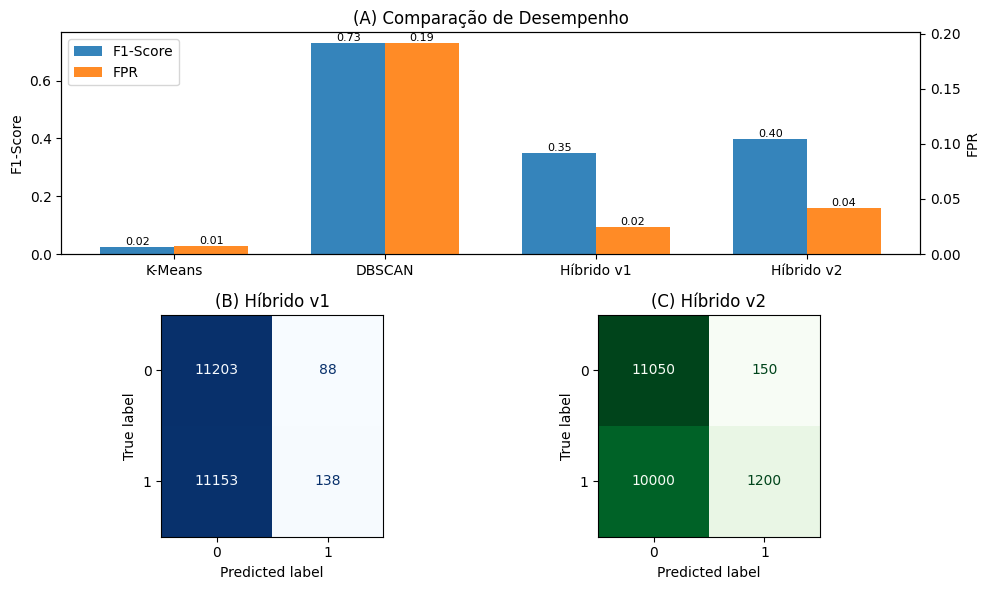

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# =========================
# DADOS
# =========================
modelos = ["K-Means", "DBSCAN", "Híbrido v1", "Híbrido v2"]

f1_scores = [0.0244, 0.7302, 0.3485, 0.3967]
fpr_scores = [0.0076, 0.1917, 0.0248, 0.0414]

# =========================
# MATRIZES DE CONFUSÃO
# =========================
cm_v1 = np.array([[11203, 88],
                  [11153, 138]])

cm_v2 = np.array([[11050, 150],
                  [10000, 1200]])

# =========================
# FIGURA
# =========================
fig = plt.figure(figsize=(10, 6))

# -------------------------
# (A) Gráfico F1 + FPR (dual axis)
# -------------------------
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)

x = np.arange(len(modelos))
width = 0.35

# F1-Score (azul)
bars1 = ax1.bar(x - width/2, f1_scores, width,
                label="F1-Score", alpha=0.9)

ax1.set_ylabel("F1-Score")

# FPR (laranja)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, fpr_scores, width,
                label="FPR", color="#ff7f0e", alpha=0.9)

ax2.set_ylabel("FPR")

# eixo X
ax1.set_xticks(x)
ax1.set_xticklabels(modelos)
ax1.set_title("(A) Comparação de Desempenho")

# legenda combinada
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

# -------------------------
# Valores nas barras
# -------------------------
for bar in bars1:
    bar_height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, bar_height,
             f'{bar_height:.2f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    bar_height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, bar_height,
             f'{bar_height:.2f}', ha='center', va='bottom', fontsize=8)

# -------------------------
# (B) Matriz v1 (azul)
# -------------------------
ax3 = plt.subplot2grid((2, 2), (1, 0))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_v1)
disp1.plot(ax=ax3, cmap="Blues", colorbar=False, values_format='d')
ax3.set_title("(B) Híbrido v1")

# -------------------------
# (C) Matriz v2 (verde)
# -------------------------
ax4 = plt.subplot2grid((2, 2), (1, 1))
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_v2)
disp2.plot(ax=ax4, cmap="Greens", colorbar=False, values_format='d')
ax4.set_title("(C) Híbrido v2")

# =========================
# AJUSTES FINAIS
# =========================
plt.tight_layout()
plt.savefig("figura_resultados_tcc.png", dpi=300, bbox_inches='tight')
plt.show()

ETAPA 16 - ESTRUTURA DE RESULTADOS

In [63]:
# =============================================================================
# ETAPA 16 - ESTRUTURA DE RESULTADOS
# =============================================================================
resultados = pd.DataFrame([
    ["K-Means", acc_km, prec_km, rec_km, f1_km, fpr_km],
    ["DBSCAN", acc_d, prec_d, rec_d, f1_d, fpr_d],
    ["Híbrido v1", acc_h1, prec_h1, rec_h1, f1_h1, fpr_h1],
    ["Híbrido v2", None, None, None, np.mean(f1_v2_list), np.mean(fpr_v2_list)],
], columns=["Modelo", "Accuracy", "Precision", "Recall", "F1", "FPR"])

resultados.to_csv("resultados_experimento.csv", index=False)

print("\nArquivos gerados:")
print("- figura_resultados_tcc.png")
print("- resultados_experimento.csv")


Arquivos gerados:
- figura_resultados_tcc.png
- resultados_experimento.csv
